# MSD Postselection Experiment

This notebook wires together the experimental `PostSelectionExperiment`
scaffold for three cases:

- distilled MSD with an MLD table decoder,
- distilled MSD with an MLE decoder,
- injected-state tomography with a degenerate no-ancilla MLD table decoder.

The default shot counts are intentionally small so the notebook can run as a
smoke test. Increase the constants below to approach the paper-scale curves.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

from bloqade.lanes import GeminiLogicalSimulator

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "demo":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from demo.msd_utils.application.experiments import (
    PostSelectionExperiment,
    empty_logical_circuit,
    magic_state_dist_steane,
    single_qubit_state_tomography,
)
from demo.msd_utils.application.table_decoders import TableDecoderWithConfidence
from demo.msd_utils.domain.confidence import ConfidenceGurobiDecoder
from demo.msd_utils.standard.tomography import DEFAULT_TARGET_BLOCH

from bloqade.gemini.decoding.workflow import plot_decoder_curves

## Configuration

In [2]:
EVAL_SHOTS = 1_000_000
MLD_TRAIN_SHOTS = 10_000_000
MLD_BATCH_SIZE = None
SIM_TYPE = "clifft"

MSD_VALID_FACTORY_TARGETS = np.array([[1, 0, 1, 1]], dtype=np.uint8)
INJECTED_VALID_FACTORY_TARGETS = np.zeros((1, 0), dtype=np.uint8)

## Shared kernels

In [3]:
primitive_set = magic_state_dist_steane()
noncliff_prefix = primitive_set.state_injection_circuit
main_cliff_circ = primitive_set.logical_circuit
tomo_circs = single_qubit_state_tomography()

Building MSD primitives...


## Experiment construction

In [4]:
def build_msd_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        MSD_VALID_FACTORY_TARGETS,
        TableDecoderWithConfidence,
        {
            "num_shots": MLD_TRAIN_SHOTS,
            "step_size": MLD_BATCH_SIZE,
        },
    )


def build_msd_mle_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        MSD_VALID_FACTORY_TARGETS,
        ConfidenceGurobiDecoder,
        {},
    )


def build_injected_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        empty_logical_circuit(),
        INJECTED_VALID_FACTORY_TARGETS,
        TableDecoderWithConfidence,
        {
            "num_shots": MLD_TRAIN_SHOTS,
            "step_size": MLD_BATCH_SIZE,
        },
    )


msd_mld_exp = build_msd_mld_experiment()
msd_mle_exp = build_msd_mle_experiment()
injected_mld_exp = build_injected_mld_experiment()

## End-to-end runner

In [5]:
def prepare_experiment(
    exp: PostSelectionExperiment,
    *,
    decoder_name: str,
    num_logical_qubits: int,
    eval_shots: int = EVAL_SHOTS,
) -> PostSelectionExperiment:
    exp.kernels(
        num_logical_qubits=num_logical_qubits,
        tomography_kernels=tomo_circs,
    )
    exp.dem_circuits()
    exp.dems()
    exp.initialize_decoders()
    exp.make_tasks(device=GeminiLogicalSimulator())
    exp.get_samples(num_shots=eval_shots, chunk_size=None, sim_type=SIM_TYPE)
    exp.decode_and_postselect(decoder_name=decoder_name)
    return exp


msd_mld_exp = prepare_experiment(
    msd_mld_exp,
    decoder_name="MLD",
    num_logical_qubits=5,
)

try:
    msd_mle_exp = prepare_experiment(
        msd_mle_exp,
        decoder_name="MLE",
        num_logical_qubits=5,
    )
except Exception as exc:
    print(f"Skipping MLE experiment because decoder construction failed: {exc!r}")
    msd_mle_exp = None

injected_mld_exp = prepare_experiment(
    injected_mld_exp,
    decoder_name="Injected MLD",
    num_logical_qubits=1,
)

100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

...

Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29


100%|██████████| 1/1 [00:00<00:00, 43.31it/s]


Injected MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

## Tomography result API

In [6]:
tomo_result = msd_mld_exp.tomography_result(
    0.05,
)
tomo_result.fidelity_bloch(DEFAULT_TARGET_BLOCH)

{'point': 0.9916359190162995}

In [7]:
tomo_result = injected_mld_exp.tomography_result(
    1.0,
)
tomo_result.fidelity_bloch(DEFAULT_TARGET_BLOCH)

{'point': 0.9652987062955725}

## Curves

In [8]:
msd_mld_curve = msd_mld_exp.analysis_f_vs_fraction(
    target_bloch=DEFAULT_TARGET_BLOCH,
)

msd_mle_curve = None
if msd_mle_exp is not None:
    msd_mle_curve = msd_mle_exp.analysis_f_vs_fraction(
        target_bloch=DEFAULT_TARGET_BLOCH,
    )

injected_curve = injected_mld_exp.analysis_f_vs_fraction(
    target_bloch=DEFAULT_TARGET_BLOCH,
)

injected_summary = injected_mld_exp.tomography_result(
    1.0,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)

## Individual visualizations

Plotting decoder curves...
Plotting decoder curves...
Plotting decoder curves...


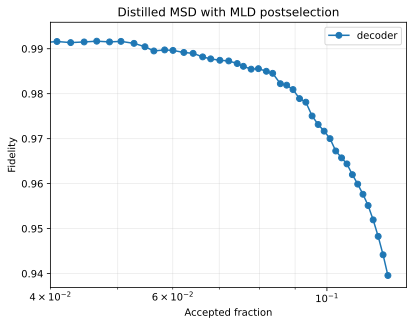

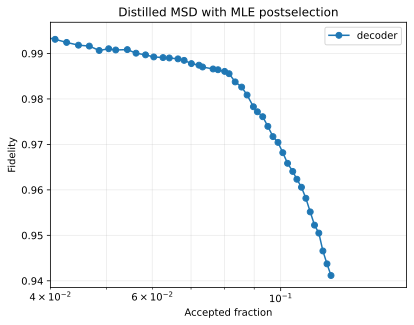

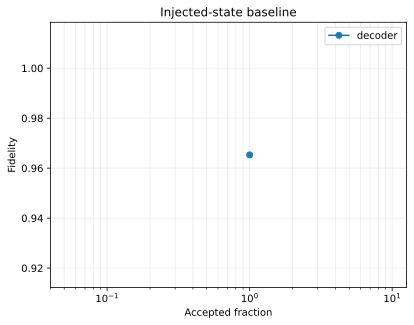

In [9]:
fig_mld, ax_mld = msd_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Distilled MSD with MLD postselection",
)

if msd_mle_exp is not None:
    fig_mle, ax_mle = msd_mle_exp.analysis_visualization(
        min_accepted_fraction=0.04,
        title="Distilled MSD with MLE postselection",
    )

fig_injected, ax_injected = injected_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Injected-state baseline",
)

## Combined figure

Plotting decoder curves...


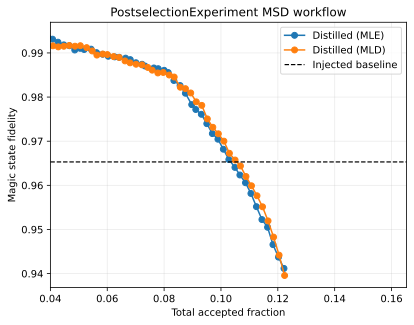

In [10]:
curves = {"Distilled (MLD)": msd_mld_curve}
if msd_mle_curve is not None:
    curves = {"Distilled (MLE)": msd_mle_curve, **curves}

fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.04,
    title="PostselectionExperiment MSD workflow",
)
ax.set_xscale("linear")
ax.set_xlabel("Total accepted fraction")
ax.set_ylabel("Magic state fidelity")
ax.legend()

# debug

In [11]:
def summarize_curve(name, curve):
    print(f"\n{name}")
    print("keys:", curve.keys())

    for key in [
        "accepted_fraction",
        "fidelity",
        "point",
    ]:
        if key not in curve:
            continue
        arr = np.asarray(curve[key])
        print(
            key,
            "shape=",
            arr.shape,
            "dtype=",
            arr.dtype,
            "min=",
            np.nanmin(arr) if arr.size else None,
            "max=",
            np.nanmax(arr) if arr.size else None,
        )


summarize_curve("MLD", msd_mld_curve)

if msd_mle_curve is not None:
    summarize_curve("MLE", msd_mle_curve)

print("\ninjected_summary")
print(injected_summary)


MLD
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity'])
accepted_fraction shape= (46,) dtype= float64 min= 0.035860666666666666 max= 0.12239133333333334
fidelity shape= (46,) dtype= float64 min= 0.9395647314653301 max= 0.993207733772518

MLE
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity'])
accepted_fraction shape= (47,) dtype= float64 min= 0.00030233333333333333 max= 0.12216566666666667
fidelity shape= (47,) dtype= float64 min= 0.9411663422116039 max= 0.9942125107102637

injected_summary
{'point': 0.9652987062955725}


Plotting decoder curves...
ylim: (np.float64(0.9368323425030834), np.float64(0.9969448996725104))
line 0 Distilled (MLE) y min/max: 0.9411663422116039 0.9942125107102637
line 1 Distilled (MLD) y min/max: 0.9395647314653301 0.993207733772518
line 2 Injected baseline y min/max: 0.9652987062955725 0.9652987062955725


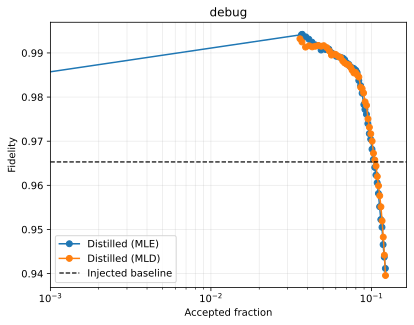

In [12]:
fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.001,
    title="debug",
)
print("ylim:", ax.get_ylim())

for i, collection in enumerate(ax.collections):
    try:
        paths = collection.get_paths()
        ys = np.concatenate(
            [
                np.asarray(p.vertices, dtype=float)[:, 1]
                for p in paths
                if np.asarray(p.vertices).size
            ]
        )
        print("collection", i, "y min/max:", np.nanmin(ys), np.nanmax(ys))
    except Exception as exc:
        print("collection", i, "could not inspect:", exc)

for i, line in enumerate(ax.lines):
    y = np.asarray(line.get_ydata(), dtype=float)
    print("line", i, line.get_label(), "y min/max:", np.nanmin(y), np.nanmax(y))